In [1]:
import os

**Dataset Link**
https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

In [3]:
# STEP 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
# Preview the train dataset
train_df = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Preview the test dataset
test_df = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [6]:
# Check for the null values
train_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [7]:
# Check the datatypes for encoding
train_df.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [8]:
# STEP 2:Encoding the categorical values
import pickle

encoders = {}
for col in train_df.columns:
    if train_df[col].dtype == 'object':
        encoder = LabelEncoder()
        train_df[col] = encoder.fit_transform(train_df[col])
        encoders[col] = encoder

with open("catgbm_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("CatGBM encoders loaded successfully!")

CatGBM encoders loaded successfully!


In [9]:
# Check the datatypes after encoding
train_df.dtypes

Id                 int64
MSSubClass         int64
MSZoning           int64
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType           int64
SaleCondition      int64
SalePrice          int64
Length: 81, dtype: object

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


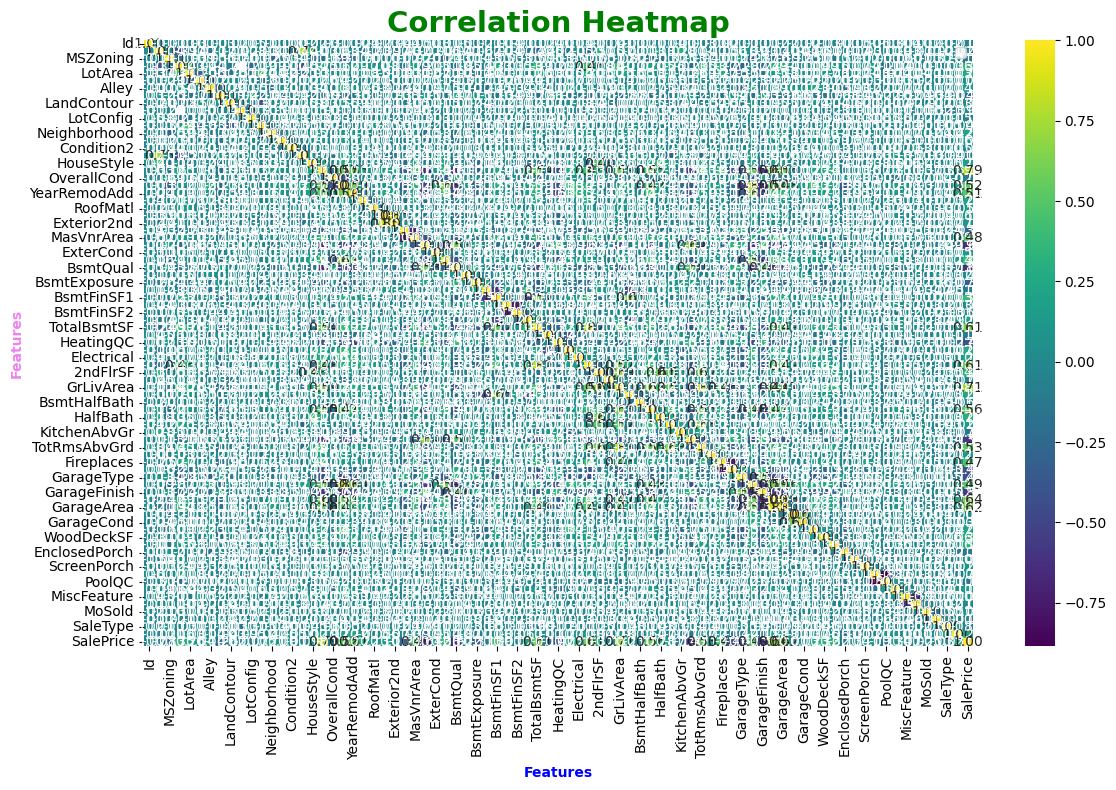

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


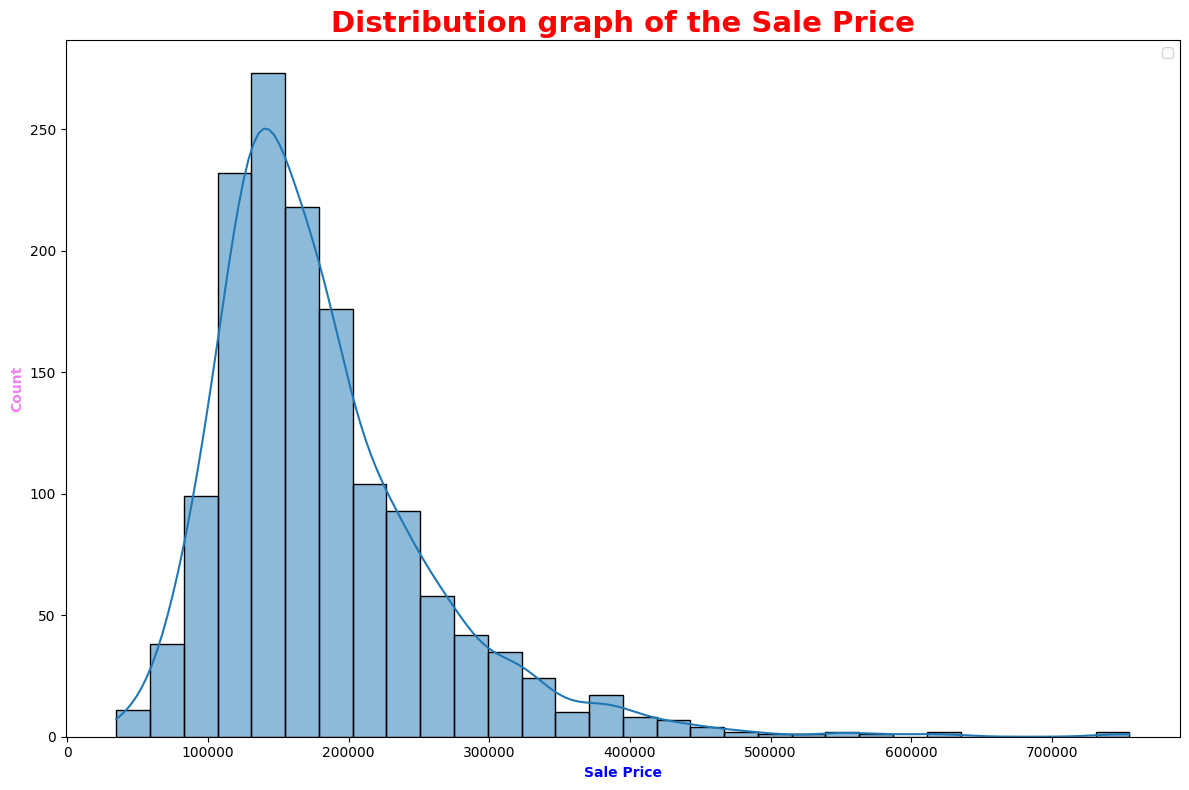

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


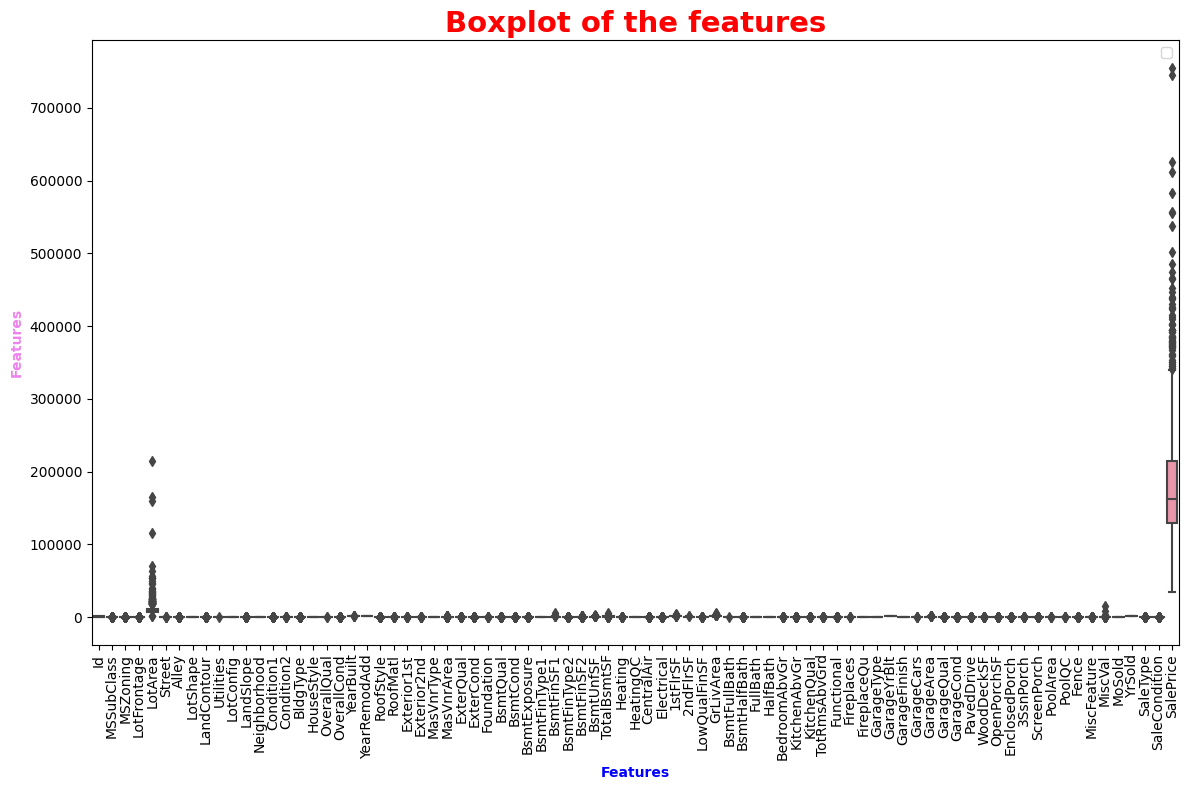

In [10]:
# STEP 3: Basic Visualizations

ze=(12,8))
sns.heatmap(train_df.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation Heatmap", color='green', fontsize=21, fontweight='bold')
plt.xlabel("Features", color='blue', fontweight='bold')
plt.ylabel("Features", color='violet', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Distribution of the target variable(Whether is skewed, left skewed, right skewed)
plt.figure(figsize=(12,8))
sns.histplot(train_df['SalePrice'], kde=True, bins=30)
plt.title("Distribution graph of the Sale Price", color='red', fontsize='21', fontweight='bold')
plt.xlabel("Sale Price", color='blue', fontweight='bold')
plt.ylabel("Count", color='violet', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Boxplot to check the outliers
plt.figure(figsize=(12,8))
sns.boxplot(data=train_df)
plt.title("Boxplot of the features", color='red', fontsize='21', fontweight='bold')
plt.xlabel("Features", color='blue', fontweight='bold')
plt.ylabel("Features", color='violet', fontweight='bold')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Remove unwanted features
train_df.drop(columns=['Id'], inplace=True)

In [12]:
# STEP 4: Extract the independent and dependent variables

X = train_df.drop(columns=['SalePrice'])
y = train_df['SalePrice']

# Split into Train and Test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
# STEP 5: Scale the dataset and save the scalers
import pickle

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler using pickle
with open("catgbm_scalers.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("CatGBM scalers dumped successfully!")

CatGBM scalers dumped successfully!


In [17]:
# STEP 6: Optuna Objective function with optimization

import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 1500),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 10.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 0.1, 10.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
        "grow_policy": trial.suggest_categorical(
            "grow_policy", ["SymmetricTree", "Depthwise", "Lossguide"]
        ),

        # GPU settings (SAFE)
        "loss_function": "RMSE",
        "task_type": "GPU",
        "devices": "0",
        "verbose": 0,
        "random_seed": 42,
    }

    model = CatBoostRegressor(**params)

    pipeline = Pipeline([
        ("model", model)
    ])

    score = cross_val_score(
        pipeline,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="r2"
    ).mean()

    return score


# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best Hyperparameters:", study.best_params)
print("Best R² Score:", study.best_value)

[I 2026-01-01 17:12:17,390] A new study created in memory with name: no-name-6e690f7a-a96d-4c52-bfa2-84b951522ea4


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-01-01 17:13:01,502] Trial 0 finished with value: 0.7512394178273307 and parameters: {'iterations': 726, 'depth': 10, 'learning_rate': 0.0022094760267385976, 'l2_leaf_reg': 9.678630252846272, 'bagging_temperature': 1.0195925198784295, 'border_count': 190, 'random_strength': 2.409374174700375, 'min_data_in_leaf': 49, 'grow_policy': 'Lossguide'}. Best is trial 0 with value: 0.7512394178273307.
[I 2026-01-01 17:13:31,548] Trial 1 finished with value: 0.8637749985202614 and parameters: {'iterations': 1480, 'depth': 5, 'learning_rate': 0.19217087846202743, 'l2_leaf_reg': 9.500099694373295, 'bagging_temperature': 8.683184414437923, 'border_count': 164, 'random_strength': 0.38607818898054713, 'min_data_in_leaf': 43, 'grow_policy': 'Lossguide'}. Best is trial 1 with value: 0.8637749985202614.
[I 2026-01-01 17:13:45,473] Trial 2 finished with value: 0.8525002448677832 and parameters: {'iterations': 481, 'depth': 8, 'learning_rate': 0.16516673870883578, 'l2_leaf_reg': 1.8221095466061257, 

In [18]:
# STEP 8 : Run the best catgbm modelfrom catboost import CatBoostRegressor

best = study.best_params

best_catgbm_model = CatBoostRegressor(
    **best,
    loss_function="RMSE",
    task_type="GPU",
    devices="0",
    random_seed=42,
    verbose=100
)

# Train
best_catgbm_model.fit(X_train_scaled, y_train)

# Predict
y_pred = best_catgbm_model.predict(X_test_scaled)

0:	learn: 74415.3832027	total: 528ms	remaining: 12m 53s
100:	learn: 21855.9303635	total: 1.3s	remaining: 17.5s
200:	learn: 16702.6361696	total: 2.03s	remaining: 12.8s
300:	learn: 13167.5050424	total: 2.74s	remaining: 10.6s
400:	learn: 10973.8214220	total: 3.43s	remaining: 9.1s
500:	learn: 9327.6708511	total: 4.12s	remaining: 7.94s
600:	learn: 7924.3878809	total: 4.84s	remaining: 6.96s
700:	learn: 6891.1641818	total: 5.57s	remaining: 6.08s
800:	learn: 6045.5151814	total: 6.27s	remaining: 5.2s
900:	learn: 5294.5183542	total: 7.05s	remaining: 4.42s
1000:	learn: 4699.3804546	total: 7.77s	remaining: 3.61s
1100:	learn: 4172.8009581	total: 8.48s	remaining: 2.81s
1200:	learn: 3742.5634757	total: 9.21s	remaining: 2.03s
1300:	learn: 3349.2564049	total: 9.93s	remaining: 1.26s
1400:	learn: 3004.7715114	total: 10.7s	remaining: 497ms
1465:	learn: 2818.7463258	total: 11.2s	remaining: 0us


In [22]:
# STEP 9: Predictions and model performance

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Train predictions
y_train_pred = best_catgbm_model.predict(X_train_scaled)

# Test predictions
y_test_pred = best_catgbm_model.predict(X_test_scaled)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Print results
print("TRAIN R²:", train_r2)
print("TEST  R²:", test_r2)

print("\nTRAIN RMSE:", train_rmse)
print("TEST  RMSE:", test_rmse)

print("\nTRAIN MAE:", train_mae)
print("TEST  MAE:", test_mae)

TRAIN R²: 0.9986679172172824
TEST  R²: 0.9024702183755137

TRAIN RMSE: 2818.736395540389
TEST  RMSE: 27351.14695904972

TRAIN MAE: 2026.098651641145
TEST  MAE: 15680.99109520527


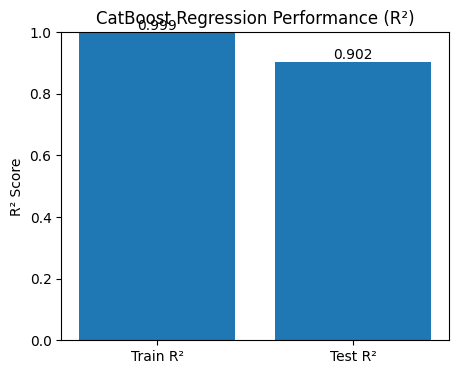

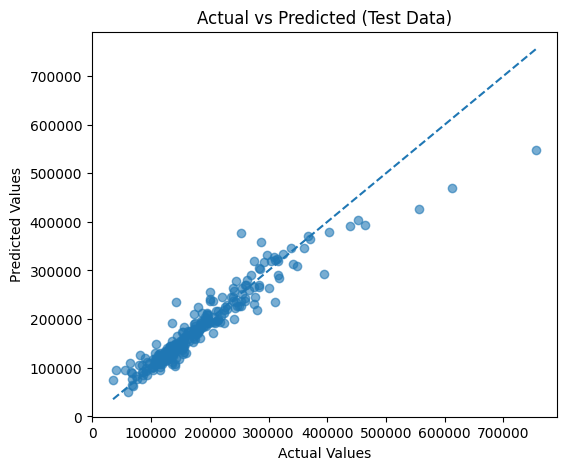

In [24]:
# STEP 10: Visulaizations of the model performances

# Predictions
y_train_pred = best_catgbm_model.predict(X_train_scaled)
y_test_pSTEP 1:red = best_catgbm_model.predict(X_test_scaled)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# ---------------- BAR PLOT (R² SCORE) ----------------
scores = [train_r2, test_r2]
labels = ["Train R²", "Test R²"]

plt.figure(figsize=(5,4))
plt.bar(labels, scores)
plt.ylim(0, 1)

for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.title("CatBoost Regression Performance (R²)")
plt.ylabel("R² Score")
plt.show()

# ---------------- ACTUAL vs PREDICTED ----------------
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Test Data)")
plt.show()

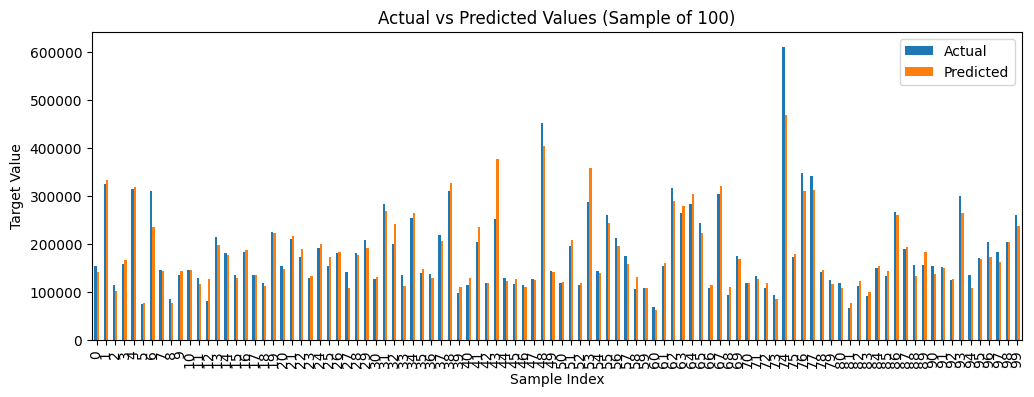

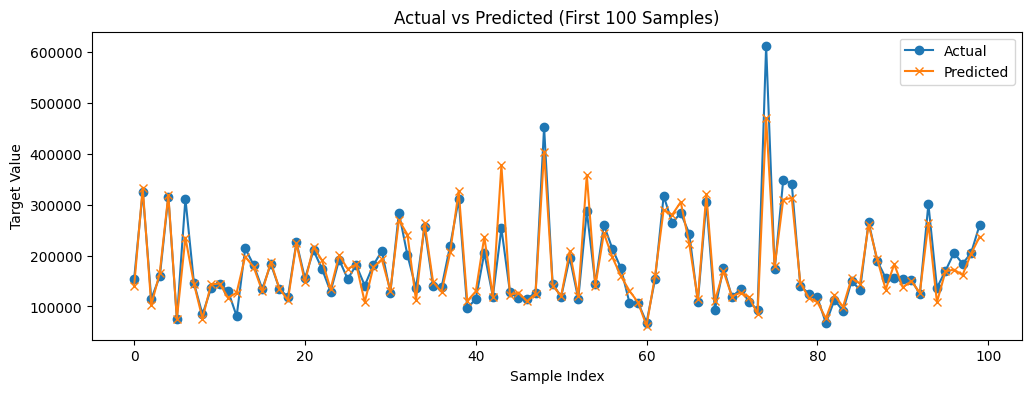

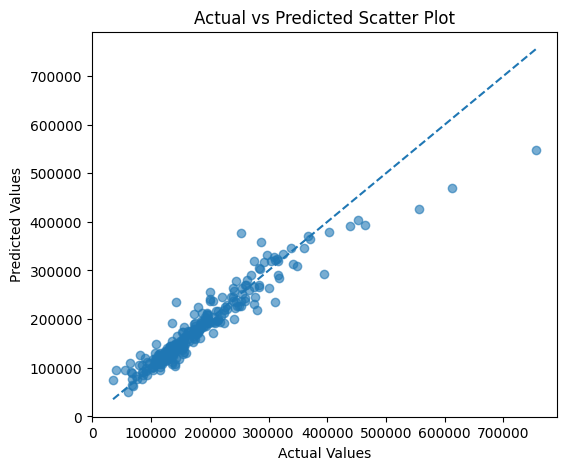

In [28]:
# STEP 11: Take first 100 samples
comparison = pd.DataFrame({
    "Actual": y_test[:100].values,
    "Predicted": y_pred[:100]
})

# ---------------- BAR PLOT ----------------
comparison.plot(kind="bar", figsize=(12,4))
plt.title("Actual vs Predicted Values (Sample of 100)")
plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.legend()
plt.show()

# ---------------- LINE PLOT ----------------
plt.figure(figsize=(12,4))
plt.plot(y_test[:100].values, label="Actual", marker='o')
plt.plot(y_pred[:100], label="Predicted", marker='x')
plt.title("Actual vs Predicted (First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.legend()
plt.show()

# Scatterplot
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Scatter Plot")
plt.show()

Predicted Transaction Value: 207888.54720008705


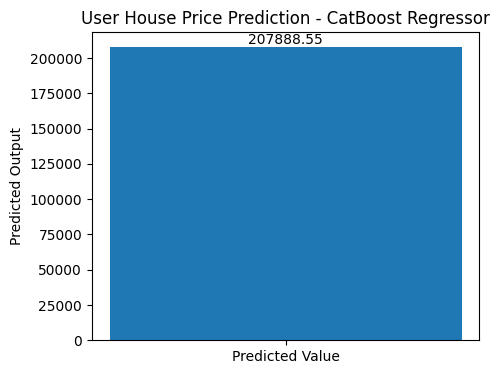

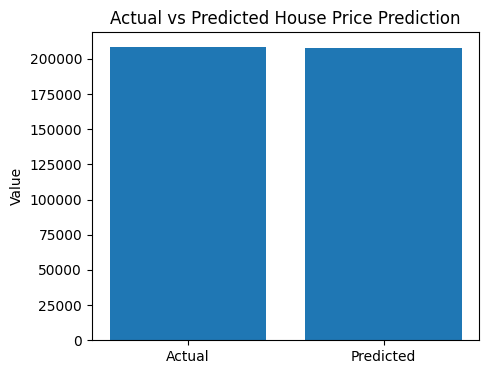

In [34]:
# STEP 12: Actual vs Predicted model check

joblib.dump(best_catgbm_model, "house_price_model.pkl")

def predict_transaction_value(user_data):
    # Load scaler and regression model
    scaler = joblib.load("catbgm_scalers.pkl")
    model = joblib.load("house_price_model.pkl")  # CatBoostRegressor

    # Scale input
    user_scaled = scaler.transform([user_data])

    # Predict continuous value
    prediction = model.predict(user_scaled)[0]

    return prediction

import matplotlib.pyplot as plt

# Example: take one real sample as user input
sample_user = X.iloc[0].values  

predicted_value = predict_transaction_value(sample_user)

print("Predicted Transaction Value:", predicted_value)

# ---------------- Visualization ----------------
plt.figure(figsize=(5,4))
plt.bar(["Predicted Value"], [predicted_value])
plt.ylabel("Predicted Output")
plt.title("User House Price Prediction - CatBoost Regressor")

# Add value label
plt.text(0, predicted_value, f"{predicted_value:.2f}", ha="center", va="bottom")
plt.show()

# Compare with actual value (if available)
actual_value = y.iloc[0]

plt.figure(figsize=(5,4))
plt.bar(["Actual", "Predicted"], [actual_value, predicted_value])
plt.ylabel("Value")
plt.title("Actual vs Predicted House Price Prediction")
plt.show()

In [45]:
# STEP 13: Save the full pipeline

joblib.dump({
    "model": best_catgbm_model,
    "scaler": scaler,
    "label_encoders": encoders
}, "house_price_full_pipeline.pkl")

print("Full pipeline saved successfully")

Full pipeline saved successfully
